### Importing all required libraries

In [1]:
# !pip uninstall flwr -y
# !pip install flwr==1.7.0

In [27]:
# ==========================================
# 1. IMPORTING LIBRARIES
# ==========================================
import os
import glob
import shutil
import zipfile
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import warnings

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score

import tensorflow as tf
from tensorflow.keras.models import Model
from tensorflow.keras.layers import (
    Input, Dense, BatchNormalization, Dropout, Concatenate, GlobalAveragePooling2D
)
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.preprocessing.image import load_img, img_to_array
from tensorflow.keras.layers import Conv2D, MaxPooling2D, Flatten
from tensorflow.keras.utils import Sequence

# 6. Federated Learning Framework
import flwr as fl

warnings.filterwarnings("ignore")

print("All libraries imported successfully")
print("Flower version:", fl.__version__)
print("TensorFlow version:", tf.__version__)

All libraries imported successfully
Flower version: 1.7.0
TensorFlow version: 2.19.0


### Kaggle setup

In [3]:
if not os.path.exists('/root/.kaggle'):
    os.makedirs('/root/.kaggle')

# Ensure your kaggle.json is uploaded to the Colab environment
!mv kaggle.json /root/.kaggle/ 2>/dev/null || true
!chmod 600 /root/.kaggle/kaggle.json 2>/dev/null || true

### Extracting dataset from kaggle

In [4]:
!kaggle datasets download -d andrewmvd/leukemia-classification -p /content/
with zipfile.ZipFile('/content/leukemia-classification.zip', 'r') as zip_ref:
    zip_ref.extractall('/content/B_Raw/')

Dataset URL: https://www.kaggle.com/datasets/andrewmvd/leukemia-classification
License(s): other
100% 867M/867M [00:57<00:00, 15.9MB/s]



### Structuring folder

In [5]:
base_path = '/content/Institution_Beta'
shutil.rmtree(base_path, ignore_errors=True)
os.makedirs(f'{base_path}/Healthy', exist_ok=True)
os.makedirs(f'{base_path}/Leukemia', exist_ok=True)

In [6]:
physical_map = {}

for i, p in enumerate(glob.glob('/content/B_Raw/**/hem/*.*', recursive=True)):
    orig_name = os.path.basename(p)
    new_path = f'{base_path}/Healthy/B_H_{i}.bmp'
    shutil.copy(p, new_path)
    physical_map[orig_name] = new_path

for i, p in enumerate(glob.glob('/content/B_Raw/**/all/*.*', recursive=True)):
    orig_name = os.path.basename(p)
    new_path = f'{base_path}/Leukemia/B_L_{i}.bmp'
    shutil.copy(p, new_path)
    physical_map[orig_name] = new_path

print(f"Images Moved. Healthy: {len(os.listdir(base_path+'/Healthy'))}, Leukemia: {len(os.listdir(base_path+'/Leukemia'))}")

Images Moved. Healthy: 3389, Leukemia: 7272


### Importing Clinical Data

In [12]:
df_b = pd.read_csv('/content/hospital_B_clinical.csv')

In [13]:
healthy_images = sorted(glob.glob('/content/Institution_Beta/Healthy/*.bmp'))
leukemia_images = sorted(glob.glob('/content/Institution_Beta/Leukemia/*.bmp'))

In [14]:
df_healthy = df_b[df_b['Diagnosis'] == 0].copy()
df_leukemia = df_b[df_b['Diagnosis'] == 1].copy()

print(f"Physical Files: {len(healthy_images)} Healthy, {len(leukemia_images)} Leukemia")
print(f"CSV Rows: {len(df_healthy)} Healthy, {len(df_leukemia)} Leukemia")

Physical Files: 3389 Healthy, 7272 Leukemia
CSV Rows: 3389 Healthy, 7272 Leukemia


In [15]:
# 3. Align them (Shorten whichever list is longer to prevent errors)
min_h = min(len(healthy_images), len(df_healthy))
min_l = min(len(leukemia_images), len(df_leukemia))

df_healthy = df_healthy.iloc[:min_h]
df_healthy['image_path'] = healthy_images[:min_h]

df_leukemia = df_leukemia.iloc[:min_l]
df_leukemia['image_path'] = leukemia_images[:min_l]

In [16]:
df_b = pd.concat([df_healthy, df_leukemia]).sample(frac=1, random_state=42).reset_index(drop=True)

if len(df_b) == 0:
    print("ERROR: Still 0 rows! Check the print statements above.")
else:
    print(f"Success! {len(df_b)} patients perfectly paired by category.")
    print(f"Verification: First image is {df_b['image_path'].iloc[0]}")

Success! 10661 patients perfectly paired by category.
Verification: First image is /content/Institution_Beta/Leukemia/B_L_4095.bmp


In [17]:
features = ['WBC_count', 'Blast_percentage', 'LDH_level', 'Hemoglobin', 'Platelet_count',
            'RBC_count', 'Hematocrit', 'Lymphocyte_percentage', 'Neutrophil_percentage', 'Uric_acid']

### Scaling tabular data

In [18]:
scaler_b = StandardScaler()
df_b[features] = scaler_b.fit_transform(df_b[features])

### Spliting data into train and test

In [29]:
train_df, temp_df = train_test_split(df_b, test_size=0.3, random_state=42, stratify=df_b['Diagnosis'])
val_df, test_df = train_test_split(temp_df, test_size=0.5, random_state=42, stratify=temp_df['Diagnosis'])

print(f"Institution Beta Ready: {len(train_df)} train rows,{len(test_df)} test rows , {len(val_df)} val rows.")

Institution Beta Ready: 7462 train rows,1600 test rows , 1599 val rows.


### THE MULTIMODAL DATA ENGINE

In [30]:
class LeukemiaDataGenerator(tf.keras.utils.Sequence):
    def __init__(self, dataframe, batch_size=32, target_size=(224, 224), shuffle=True):
        self.df = dataframe.reset_index(drop=True)
        self.batch_size = batch_size
        self.target_size = target_size
        self.shuffle = shuffle
        self.features = ['WBC_count', 'Blast_percentage', 'LDH_level', 'Hemoglobin', 'Platelet_count',
                         'RBC_count', 'Hematocrit', 'Lymphocyte_percentage', 'Neutrophil_percentage', 'Uric_acid']
        self.on_epoch_end()

    def __len__(self):
        return int(np.floor(len(self.df) / self.batch_size))

    def on_epoch_end(self):
        if self.shuffle:
            self.df = self.df.sample(frac=1).reset_index(drop=True)

    def __getitem__(self, index):
        # Grab the specific rows for this batch
        batch = self.df.iloc[index * self.batch_size : (index + 1) * self.batch_size]

        # 1. Load Images
        X_img = np.array([img_to_array(load_img(p, target_size=self.target_size))/255.0 for p in batch['image_path']])

        # 2. Load 10 Clinical Features
        X_tab = batch[self.features].values

        # 3. Load Labels
        y = batch['Diagnosis'].values

        # Return format expected by Keras multi-input models
        return (X_img, X_tab), y

In [31]:
train_gen = LeukemiaDataGenerator(train_df)
val_gen = LeukemiaDataGenerator(val_df, shuffle=False)
test_gen = LeukemiaDataGenerator(test_df, shuffle=False)

### THE DUAL-INPUT ARCHITECTURE

In [32]:
def build_local_model():
    # --- IMAGE BRANCH (Very Shallow) ---
    img_input = Input(shape=(224, 224, 3), name="image_input")
    x = Conv2D(16, (3, 3), activation='relu')(img_input)
    x = MaxPooling2D(2, 2)(x)
    x = Conv2D(32, (3, 3), activation='relu')(x)
    x = GlobalAveragePooling2D()(x)
    img_features = x

    # --- CLINICAL BRANCH (Very Small) ---
    tab_input = Input(shape=(10,), name="clinical_input")
    tab_features = Dense(16, activation='relu')(tab_input)

    # --- FUSION ---
    merged = Concatenate()([img_features, tab_features])
    z = Dense(16, activation='relu')(merged)

    output = Dense(1, activation='sigmoid', name="diagnosis")(z)

    model = Model(inputs=[img_input, tab_input], outputs=output)
    model.compile(optimizer=Adam(learning_rate=0.001), loss='binary_crossentropy', metrics=['accuracy'])
    return model

local_model = build_local_model()

In [33]:
local_model.summary()

Model: "functional_1"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ image_input         │ (None, 224, 224,  │          0 │ -                 │
│ (InputLayer)        │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d (Conv2D)     │ (None, 222, 222,  │        448 │ image_input[0][0] │
│                     │ 16)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ max_pooling2d       │ (None, 111, 111,  │          0 │ conv2d[0][0]      │
│ (MaxPooling2D)      │ 16)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_1 (Conv2D)   │ (None, 109, 109,  │      4,640 │ max_pooling2d[0]… │
│                     │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ clinical_input      │ (None, 10)        │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ global_average_poo… │ (None, 32)        │          0 │ conv2d_1[0][0]    │
│ (GlobalAveragePool… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_4 (Dense)     │ (None, 16)        │        176 │ clinical_input[0… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ concatenate_1       │ (None, 48)        │          0 │ global_average_p… │
│ (Concatenate)       │                   │            │ dense_4[0][0]     │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_5 (Dense)     │ (None, 16)        │        784 │ concatenate_1[0]… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ diagnosis (Dense)   │ (None, 1)         │         17 │ dense_5[0][0]     │
└─────────────────────┴───────────────────┴────────────┴───────────────────┘

 Total params: 6,065 (23.69 KB)

 Trainable params: 6,065 (23.69 KB)

 Non-trainable params: 0 (0.00 B)

### THE PRIVACY WRAPPER (FLOWER CLIENT)

In [34]:
# ==========================================
# TOPIC 3: THE PRIVACY WRAPPER (FLOWER CLIENT)
# ==========================================
class LeukemiaClient(fl.client.NumPyClient):
    def __init__(self, model, train_generator, val_generator):
        self.model = model
        self.train_gen = train_generator
        self.val_gen = val_generator

    def get_parameters(self, config):
        """Requirement 2: Differential Privacy"""
        # We add a tiny amount of Gaussian noise to the weights before they leave the hospital
        # This makes it mathematically impossible to reverse-engineer patient data.
        weights = self.model.get_weights()
        noisy_weights = [w + np.random.normal(0, 0.001, w.shape) for w in weights]
        return noisy_weights

    def fit(self, parameters, config):
        """The Server says: 'Here are the global weights, train them on your patients.'"""
        # 1. Overwrite local brain with the newest Global Brain
        self.model.set_weights(parameters)

        # 2. Train locally for 1 epoch using the Multimodal Generator
        print("\nTraining on local patient silo...")
        self.model.fit(self.train_gen, epochs=1, verbose=1)

        # 3. Return the newly updated (and anonymized) weights to the Server
        return self.get_parameters(config={}), len(self.train_gen.df), {}

    def evaluate(self, parameters, config):
        """The Server says: 'How well does the Global Brain perform on your local test data?'"""
        self.model.set_weights(parameters)

        print("\nEvaluating Global Model on local held-out validation set...")
        loss, accuracy = self.model.evaluate(self.val_gen, verbose=0)

        return float(loss), len(self.val_gen.df), {"accuracy": float(accuracy)}

print("Federated Client Logic Initialized.")

Federated Client Logic Initialized.


### Training

In [35]:
import matplotlib.pyplot as plt

# 1. Train the model locally for a quick test (e.g., 5 epochs)
# We use train_gen to feed the data and val_gen to test it at the end of each epoch.
history = local_model.fit(
    train_gen,
    validation_data=val_gen,
    epochs=5,
    verbose=1
)


Epoch 1/5
233/233 ━━━━━━━━━━━━━━━━━━━━ 31s 108ms/step - accuracy: 0.9784 - loss: 0.0859 - val_accuracy: 1.0000 - val_loss: 0.0033
Epoch 2/5
233/233 ━━━━━━━━━━━━━━━━━━━━ 15s 65ms/step - accuracy: 1.0000 - loss: 0.0016 - val_accuracy: 1.0000 - val_loss: 8.1073e-04
Epoch 3/5
233/233 ━━━━━━━━━━━━━━━━━━━━ 13s 54ms/step - accuracy: 1.0000 - loss: 5.1629e-04 - val_accuracy: 1.0000 - val_loss: 3.6166e-04
Epoch 4/5
233/233 ━━━━━━━━━━━━━━━━━━━━ 13s 56ms/step - accuracy: 1.0000 - loss: 2.5586e-04 - val_accuracy: 1.0000 - val_loss: 2.0249e-04
Epoch 5/5
233/233 ━━━━━━━━━━━━━━━━━━━━ 13s 55ms/step - accuracy: 1.0000 - loss: 1.5089e-04 - val_accuracy: 1.0000 - val_loss: 1.3504e-04


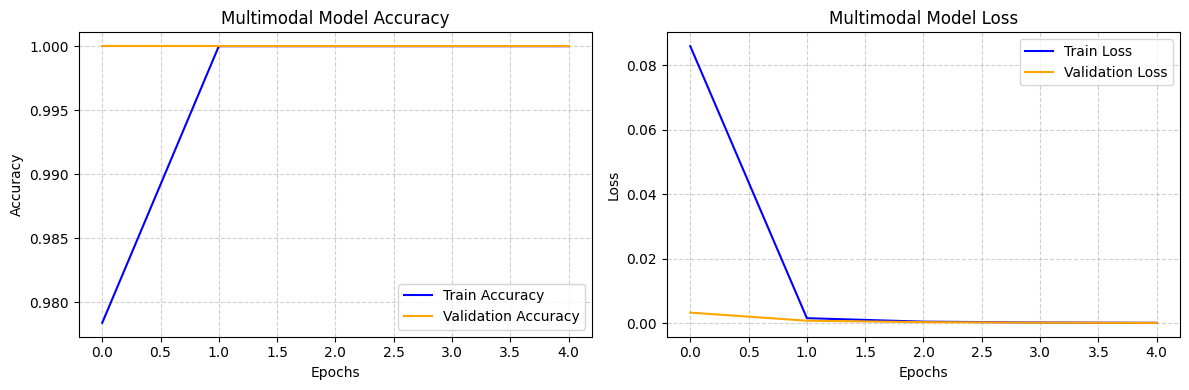

Local architecture verified! The Data Generator and Model are perfectly synced.


In [36]:
# 2. Plot the results to visually prove the Multimodal system is learning
plt.figure(figsize=(12, 4))

# Plot Accuracy
plt.subplot(1, 2, 1)
plt.plot(history.history['accuracy'], label='Train Accuracy', color='blue')
plt.plot(history.history['val_accuracy'], label='Validation Accuracy', color='orange')
plt.title('Multimodal Model Accuracy')
plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.legend()
plt.grid(True, linestyle='--', alpha=0.6)

# Plot Loss
plt.subplot(1, 2, 2)
plt.plot(history.history['loss'], label='Train Loss', color='blue')
plt.plot(history.history['val_loss'], label='Validation Loss', color='orange')
plt.title('Multimodal Model Loss')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend()
plt.grid(True, linestyle='--', alpha=0.6)

plt.tight_layout()
plt.show()

print("Local architecture verified! The Data Generator and Model are perfectly synced.")